<a href="https://colab.research.google.com/github/Snjkmr162/The_Pricing_Analytics_Toolkit/blob/main/notebooks/week3_dashboard/Week3_Price_Volume_Margin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()  # upload kaggle.json when prompted
os.makedirs('/root/.kaggle', exist_ok=True)

Saving kaggle.json to kaggle.json


In [3]:
kaggle_files = glob.glob('/content/kaggle*.json')
print(f"Found: {kaggle_files}")
!cp "{kaggle_files[0]}" /root/.kaggle/kaggle.json
!chmod 600 /root/.kaggle/kaggle.json

Found: ['/content/kaggle.json']


In [4]:
!pip install -q kaggle
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting
!unzip -o walmart-recruiting-store-sales-forecasting.zip -d walmart_data
!unzip -o walmart_data/train.csv.zip -d walmart_data
!unzip -o walmart_data/test.csv.zip -d walmart_data
!unzip -o walmart_data/features.csv.zip -d walmart_data

100% 2.70M/2.70M [00:01<00:00, 2.69MB/s]

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: walmart_data/features.csv.zip  
  inflating: walmart_data/sampleSubmission.csv.zip  
  inflating: walmart_data/stores.csv  
  inflating: walmart_data/test.csv.zip  
  inflating: walmart_data/train.csv.zip  
Archive:  walmart_data/train.csv.zip
  inflating: walmart_data/train.csv  
Archive:  walmart_data/test.csv.zip
  inflating: walmart_data/test.csv   
Archive:  walmart_data/features.csv.zip
  inflating: walmart_data/features.csv  


In [5]:
train = pd.read_csv("walmart_data/train.csv", parse_dates=["Date"])
features = pd.read_csv("walmart_data/features.csv", parse_dates=["Date"])
stores = pd.read_csv("walmart_data/stores.csv")

df = train.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores, on="Store", how="left")

markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

print(f"Data loaded: {df.shape}")
print(df.head(3))

Data loaded: (421570, 16)
   Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0      1     1 2010-02-05      24924.50      False        42.31       2.572   
1      1     1 2010-02-12      46039.49       True        38.51       2.548   
2      1     1 2010-02-19      41595.55      False        39.93       2.514   

   MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0        NaN        NaN        NaN        NaN        NaN  211.096358   
1        NaN        NaN        NaN        NaN        NaN  211.242170   
2        NaN        NaN        NaN        NaN        NaN  211.289143   

   Unemployment Type    Size  
0         8.106    A  151315  
1         8.106    A  151315  
2         8.106    A  151315  


In [6]:
# We'll use Store 1 across all departments as our base since we know it well from Weeks 1 and 2
store1 = df[df["Store"] == 1].copy()

top_depts = (store1.groupby("Dept")["Weekly_Sales"]
             .sum()
             .sort_values(ascending=False)
             .head(5)
             .index.tolist())

print(f"Top 5 departments by total sales in Store 1: {top_depts}")

store1_top = store1[store1["Dept"].isin(top_depts)].copy()
store1_top = store1_top.sort_values(["Dept", "Date"]).reset_index(drop=True)

print(f"\nRows in working dataset: {store1_top.shape[0]}")
print(f"Date range: {store1_top['Date'].min().date()} to {store1_top['Date'].max().date()}")

Top 5 departments by total sales in Store 1: [92, 95, 90, 38, 93]

Rows in working dataset: 715
Date range: 2010-02-05 to 2012-10-26


In [7]:
def build_pvm_dataset(df_subset, base_price=50, cogs_pct=0.60):
    """
    Build a Price-Volume-Margin dataset from Walmart sales data.

    Assumptions (all documented):
    - Price: derived from normalized sales (inverse relationship)
    - Volume: implied units = weekly_sales / own_price
    - COGS: 60% of price (standard retail gross margin assumption)
    - Gross Margin: (price - cost) * volume
    """
    result = df_subset.copy()

    # Derive price per department (normalize within each dept)
    result["own_price"] = result.groupby("Dept")["Weekly_Sales"].transform(
        lambda x: base_price * (1.2 - 0.4 * (x - x.min()) / (x.max() - x.min() + 1e-9))
    )

    # Derive volume (implied units sold)
    result["volume"] = result["Weekly_Sales"] / result["own_price"]

    # Derive margin components
    result["cost_per_unit"] = result["own_price"] * cogs_pct
    result["gross_margin_per_unit"] = result["own_price"] - result["cost_per_unit"]
    result["total_gross_margin"] = result["gross_margin_per_unit"] * result["volume"]
    result["margin_pct"] = (1 - cogs_pct) * 100  # 40% for all, by assumption

    return result

pvm_df = build_pvm_dataset(store1_top)

print("Documented assumptions:")
print("  Price:  derived from normalized weekly sales (inverse, $40-$60 range)")
print("  Volume: implied units = Weekly_Sales / own_price")
print("  COGS:   60% of price (standard retail gross margin assumption)")
print("  Margin: 40% gross margin (1 - COGS%)\n")

print("PVM dataset summary by department:")
summary = pvm_df.groupby("Dept").agg(
    Avg_Price=("own_price", "mean"),
    Avg_Volume=("volume", "mean"),
    Avg_Weekly_Sales=("Weekly_Sales", "mean"),
    Avg_Gross_Margin=("total_gross_margin", "mean")
).round(2)
print(summary.to_string())

Documented assumptions:
  Price:  derived from normalized weekly sales (inverse, $40-$60 range)
  Volume: implied units = Weekly_Sales / own_price
  COGS:   60% of price (standard retail gross margin assumption)
  Margin: 40% gross margin (1 - COGS%)

PVM dataset summary by department:
      Avg_Price  Avg_Volume  Avg_Weekly_Sales  Avg_Gross_Margin
Dept                                                           
38        53.32     1523.59          79978.22          31991.29
90        53.94     1545.15          82427.55          32971.02
92        53.40     2573.49         135458.97          54183.59
93        52.25     1396.92          71699.18          28679.67
95        50.11     2438.35         120772.06          48308.82


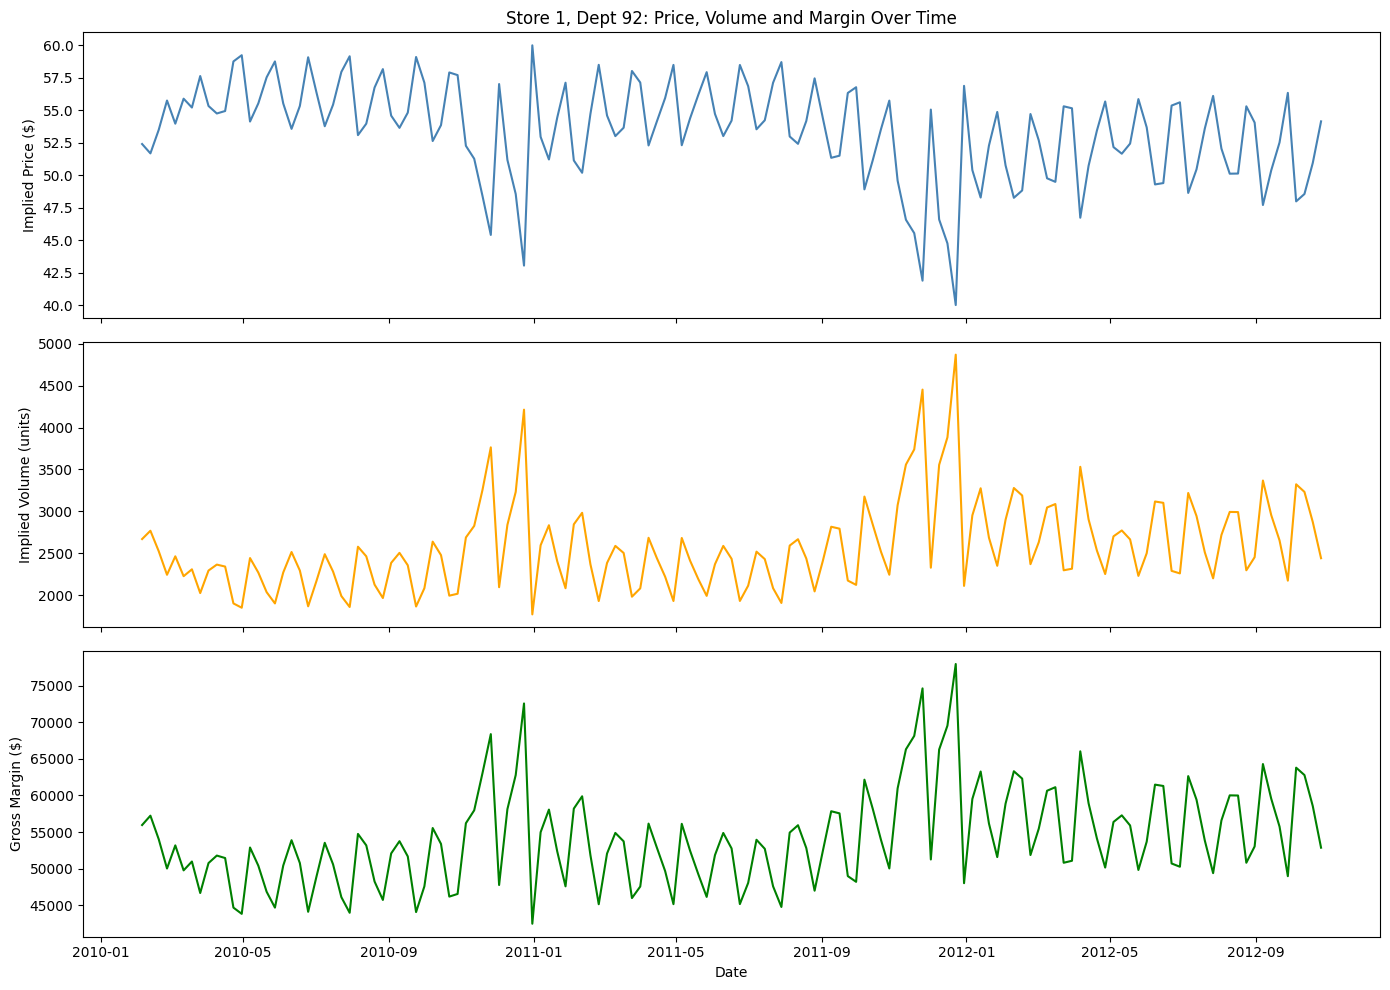

In [8]:
# Use the highest sales department as the showcase
top_dept = top_depts[0]
dept_data = pvm_df[pvm_df["Dept"] == top_dept].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(dept_data["Date"], dept_data["own_price"],
             color="steelblue", linewidth=1.5)
axes[0].set_ylabel("Implied Price ($)")
axes[0].set_title(f"Store 1, Dept {top_dept}: Price, Volume and Margin Over Time")

axes[1].plot(dept_data["Date"], dept_data["volume"],
             color="orange", linewidth=1.5)
axes[1].set_ylabel("Implied Volume (units)")

axes[2].plot(dept_data["Date"], dept_data["total_gross_margin"],
             color="green", linewidth=1.5)
axes[2].set_ylabel("Gross Margin ($)")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.savefig("week3_day11_pvm_base.png", dpi=150)
plt.show()